![Advertising](img/advertising.jpeg)

**Prédire les ventes à partir des investissements publicitaires**

**Contexte** :

Une entreprise souhaite mieux comprendre l’impact de ses dépenses publicitaires sur ses ventes. Elle dispose d’un jeu de données ([`data/advertising.csv`](data/advertising.csv)) comprenant les montants investis dans trois canaux de communication (TV, radio, presse écrite) ainsi que les ventes correspondantes. Vous êtes chargé·e d’exploiter ces données pour construire un modèle de prédiction fiable.

⸻

🎯 **Objectif** :

Construire un modèle de régression linéaire permettant de prédire les ventes en fonction des investissements publicitaires dans les trois médias, en suivant un pipeline de modélisation complet.

- Exploration des données (EDA) :
    - Analyse descriptive
    - Visualisation des relations entre variables
    - Identification des corrélations
- Préparation des données :
    - Nettoyage des données (valeurs manquantes, outliers)
    - Normalisation ou standardisation si nécessaire
    - Séparation train/test
- Modélisation :
    - Implémentation d’un modèle de régression linéaire
- Évaluation :
    - Utilisation de métriques pertinentes : RMSE, R², MAE
- Intégration simple du modèle dans un script interactif
    - Intégrer votre modèle dans un script Python simple qui permet à un utilisateur de faire une prédiction à partir de nouvelles données.

La premiere étape du l'analyse de données et de prendre connaissance du fichier csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib as plt
import sklearn as sk

df =pd.read_csv("data/advertising.csv")
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


On constate que fichier comprend 4 colonnes, qu'il ne comprend pas de valeur manquante et que les données sont des données numériques de type float64. 

In [5]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


On regarde ensuite les Kips et indice de disparités de notre fichiers csv, notamment la moyenne la mediane le min et le max ainsi que le 25% et le 75%

In [ ]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


On constate que la moyenne; mean et la médiane; 50% on des valeurs proches, ce qui nous informe d'une repartition homogénes des données et des variations de prix en fonction des valeurs. 

Puisque nous avions constaté qu'il n'y avait pas valeurs manquantes dans notre csv nous n'avons pas besoin d'utiliser la fonction dropna(). Autrement dans notre cas nous auront pu soit utilisé la moyenne ou la médiane, car elles ont des valeurs proches pour remplir les cellules vides. Sinon l'inverse aurait été observé, nous aurions utilisé la médiane pour ne pas impacter les données de notre csv. 

La prochaine étape de notre analyse consiste à visualiser l'impact des ventes par rapport aux médias de communication déployé, et voir comment ceci impacte nos ventes. 

Pour ce faire nous allons Matplotlib. 

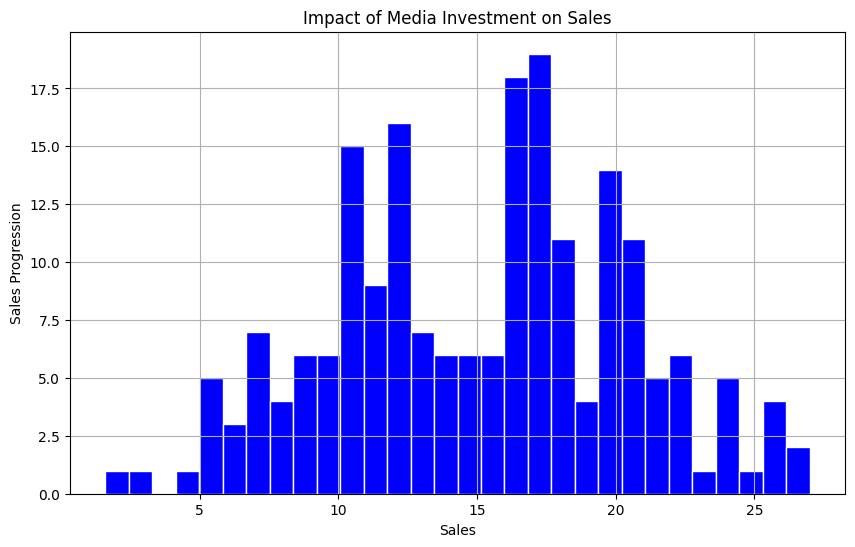

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(df['Sales'], bins=30, color='blue', edgecolor='white')
plt.title('Impact of Media Investment on Sales')
plt.xlabel('Sales')
plt.ylabel('Sales Progression')
plt.grid(True)
plt.show()


La premiére observation que nous faisons sur l'impact des investissement médias sur les ventes est que les investissement média impacte possitivement les ventes. Plus on augmente les investissement médias plus nos ventes augmentent.  


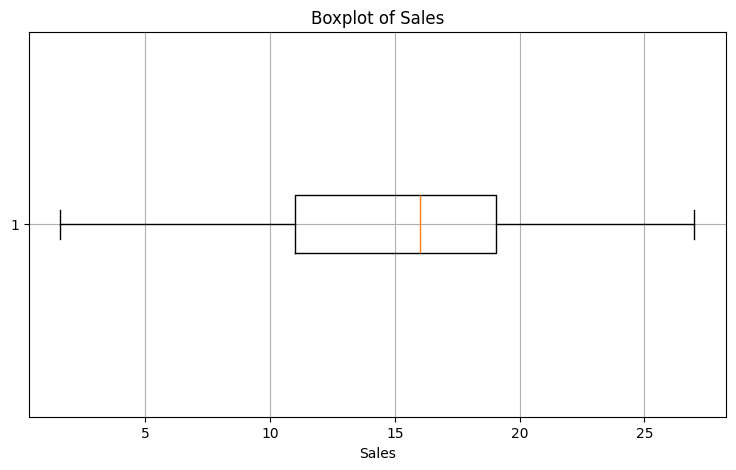

In [19]:
plt.figure(figsize=(9, 5))
plt.boxplot(df['Sales'], vert=False)
plt.title("Boxplot of Sales")
plt.xlabel("Sales")
plt.grid(True)
plt.show()

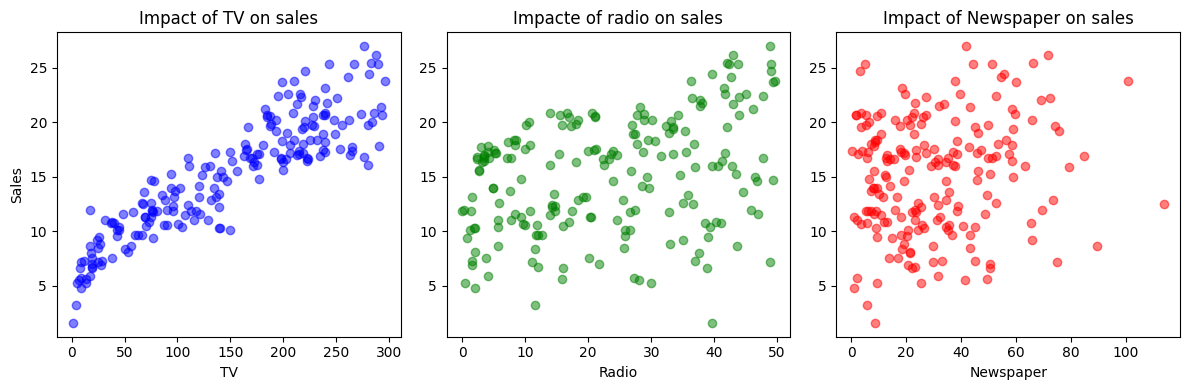

In [26]:
import matplotlib.pyplot as plt

# Créer 3 subplots côte à côte
fig, axs = plt.subplots(1, 3, figsize=(12, 4))

# Impact of TV on Sales
axs[0].scatter(df['TV'], df['Sales'], color='blue', alpha=0.5)
axs[0].set_title('Impact of TV on sales')
axs[0].set_xlabel('TV')
axs[0].set_ylabel('Sales')

# Impact of Radio on Sales
axs[1].scatter(df['Radio'], df['Sales'], color='green', alpha=0.5)
axs[1].set_title('Impacte of radio on sales')
axs[1].set_xlabel('Radio')

# Impact of Newspaper on Sales
axs[2].scatter(df['Newspaper'], df['Sales'], color='red', alpha=0.5)
axs[2].set_title('Impact of Newspaper on sales')
axs[2].set_xlabel('Newspaper')

plt.tight_layout()
plt.show()


In [27]:
df.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.901208
Radio,0.054809,1.000000,0.354104,0.349631
Newspaper,0.056648,0.354104,1.000000,0.157960
Sales,0.901208,0.349631,0.157960,1.000000


In [126]:
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return Q1, Q3, outliers

print("Outliers in Sales:\n", detect_outliers(df, 'Sales')[2],"\n")
print("Outliers in TV:\n", detect_outliers(df, 'TV')[2],"\n")
print("Outliers in Radio:\n", detect_outliers(df, 'Radio')[2],"\n")
print("Outliers in Newspaper:\n", detect_outliers(df, 'Newspaper')[2],"\n")


Outliers in Sales:
 Empty DataFrame
Columns: [TV, Radio, Newspaper, Sales]
Index: [] 

Outliers in TV:
 Empty DataFrame
Columns: [TV, Radio, Newspaper, Sales]
Index: [] 

Outliers in Radio:
 Empty DataFrame
Columns: [TV, Radio, Newspaper, Sales]
Index: [] 

Outliers in Newspaper:
 Empty DataFrame
Columns: [TV, Radio, Newspaper, Sales]
Index: [] 



In [128]:

def clear_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_clean = df[(df[column] > lower_bound) & (df[column] < upper_bound)]
    return df_clean

# Remove outliers from Newspaper column
df_clean = clear_outliers(df, 'Newspaper')

In [127]:
# 1. Copier le DataFrame original AVANT nettoyage
df = pd.read_csv('data/advertising.csv') 
df_before = df.copy()

# 2. Nettoyer les outliers dans la colonne 'Newspaper'
df = clear_outliers(df, 'Newspaper')

# 3. Afficher la taille avant et après nettoyage
print("Avant nettoyage :", df_before.shape)
print("Après nettoyage :", df.shape)


Avant nettoyage : (200, 4)
Après nettoyage : (198, 4)


In [129]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [131]:
import sklearn as sk
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))


In [138]:
# Create a Linear Regression model
model = LinearRegression()
# Fit the model to the training data
model.fit(X_train_scaled, y_train_scaled)


LinearRegression()

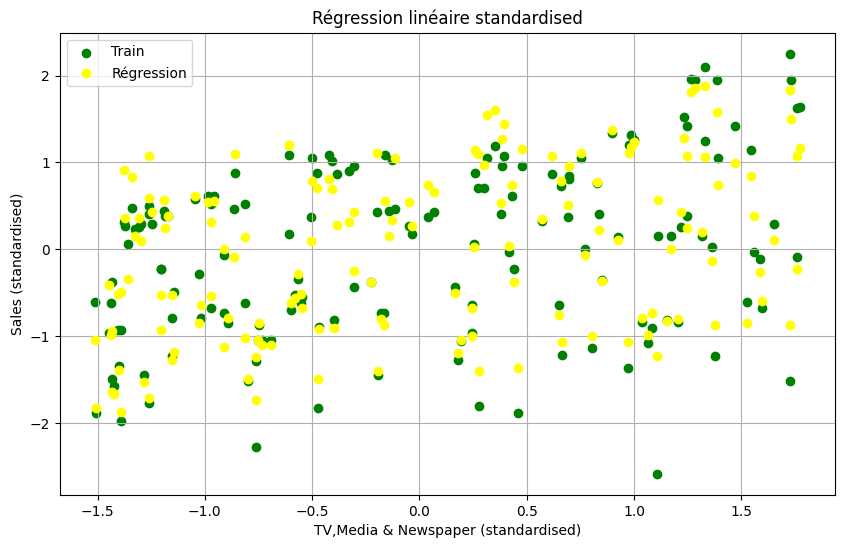

In [173]:
y_train_pred_scaled = model.predict(X_train_scaled)


plt.figure(figsize=(10, 6))
plt.scatter(X_train_scaled[:,1], y_train_scaled, color='green', label='Train')
plt.plot(X_train_scaled[:,1], y_train_pred_scaled, color='yellow', label='Régression', linestyle='None',marker='o')
plt.title("Régression linéaire standardised")
plt.xlabel("TV,Media & Newspaper (standardised)")
plt.ylabel("Sales (standardised)")
plt.legend()
plt.grid(True)
plt.show()

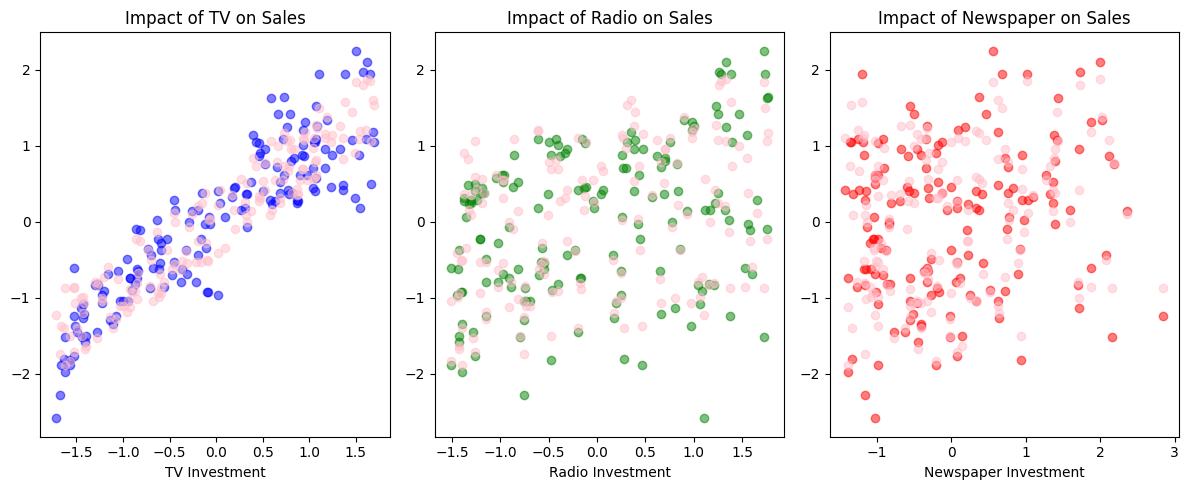

In [ ]:
y_train_pred_scaled = model.predict(X_train_scaled)

# subplots creation
fig, axs = plt.subplots(1, 3, figsize=(12, 5))

# Features's names and colors
X = ['TV', 'Radio', 'Newspaper']
colors = ['blue', 'green', 'red']

for i in range(3):  # axis 0, 1, 2
    axs[i].scatter(X_train_scaled[:, i], y_train_scaled, color=colors[i], alpha=0.5, label='Train')
    axs[i].scatter(X_train_scaled[:, i], y_train_pred_scaled, color='pink', alpha=0.5, marker='o', label='Prédiction')

    axs[i].set_title(f'Impact of {X[i]} on Sales')
    axs[i].set_xlabel(f'{X[i]} Investment')

if i == 0:
    axs[i].set_ylabel('Sales')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.show()


In [109]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred_scaled = model.predict(X_test_scaled)
mse_train = mean_squared_error(y_test_scaled, y_pred_scaled)
print("MSE :", mse_train)
print("RMSE :", np.sqrt(mse_train))
print("R² :", r2_score(y_test_scaled, y_pred_scaled))

MSE : 0.08756042334222096
RMSE : 0.29590610561835484
R² : 0.9130003152798273


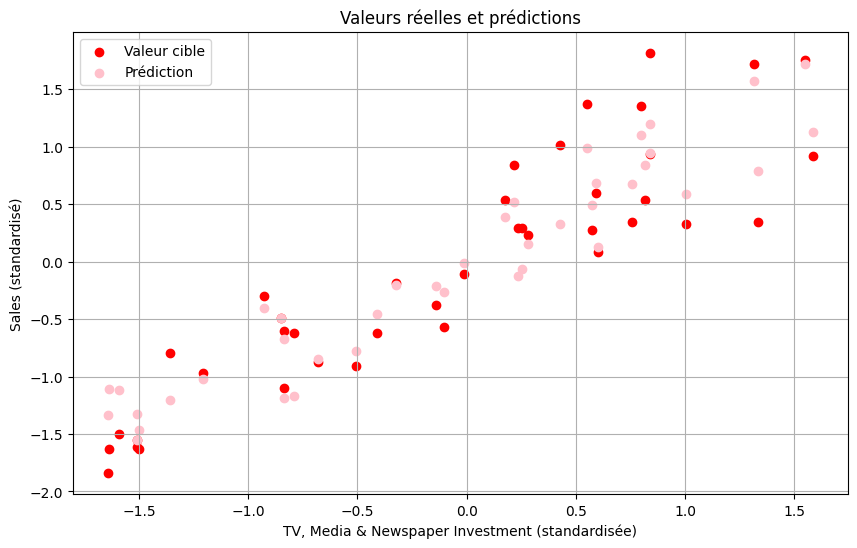

In [153]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test_scaled[:,0], y_test_scaled, color='red', label='Valeur cible')
plt.scatter(X_test_scaled[:,0], y_pred_scaled, color='pink', label='Prédiction')
plt.title("Valeurs réelles et prédictions")
plt.xlabel("TV, Media & Newspaper Investment (standardisée)")
plt.ylabel("Sales (standardisé)")
plt.legend()
plt.grid(True)
plt.show()

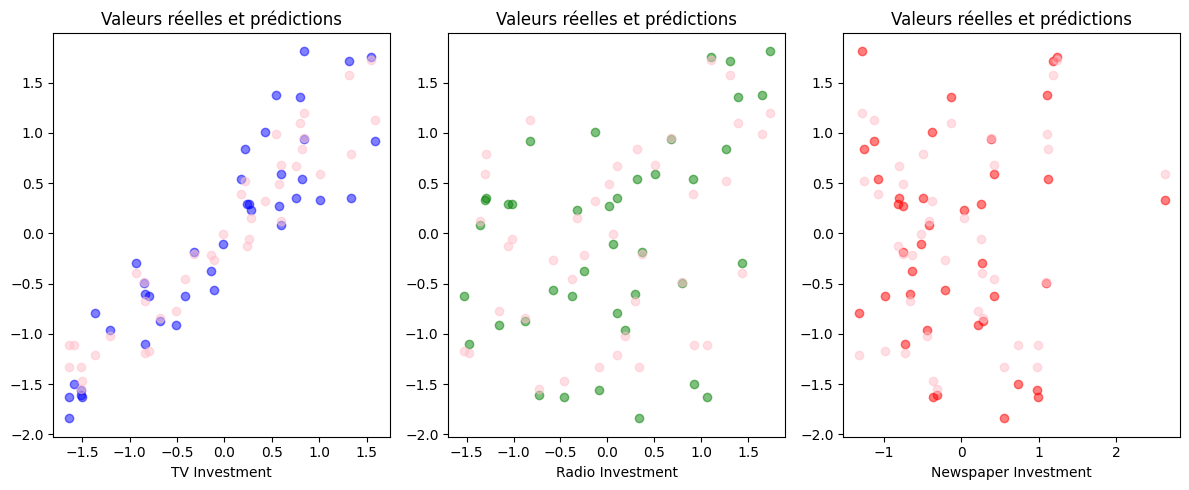

In [174]:
#subplots creation
fig, axs = plt.subplots(1, 3, figsize=(12, 5))

# Features's names and colors
X = ['TV', 'Radio', 'Newspaper']
colors = ['blue', 'green', 'red']

for i in range(3):  # axis 0, 1, 2
    axs[i].scatter(X_test_scaled[:, i], y_test_scaled, color=colors[i], alpha=0.5, label='Test')
    axs[i].scatter(X_test_scaled[:, i], y_pred_scaled, color='pink', alpha=0.5, marker='o', label='Prédiction')

    axs[i].set_title('Valeurs réelles et prédictions')
    axs[i].set_xlabel(f'{X[i]} Investment')

if i == 0:
    axs[i].set_ylabel('Sales')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.show()



In [177]:
import joblib

# Sauvegarde du modèle de régression
joblib.dump(model, "TRAIN/TRAIN_regression.pkl")

# Sauvegarde du standardiseur des variables explicatives (X)
joblib.dump(scaler_X, "TRAIN/scaler_X.pkl")

# Sauvegarde du standardiseur de la variable cible (y), si utilisé (ex : pour une régression)
joblib.dump(scaler_y, "TRAIN/scaler_y.pkl")

['TRAIN/scaler_y.pkl']

In [183]:
# Ulisation du modèle

# 1. Charger le modèle et les scalers
loaded_model = joblib.load("TRAIN/TRAIN_regression.pkl")
loaded_scaler_X = joblib.load("TRAIN/scaler_X.pkl")
loaded_scaler_y = joblib.load("TRAIN/scaler_y.pkl")

# 2. Transformer l’entrée
TV = np.array([[700]])  # Attention à la double paire de crochets pour une forme 2D
Radio = np.array([[100]])
Newspaper = np.array([[30]])
sales_scaled = loaded_scaler_X.transform(np.concatenate((TV, Radio, Newspaper), axis=1))



# 3. Prédiction standardisée
sales_scaled = loaded_model.predict(sales_scaled)

# 4. Revenir à l’échelle réelle
real_sales = loaded_scaler_y.inverse_transform(sales_scaled)

print(f"Les ventes prévisionnelles pour un investissement de 700 € TV, 100€ Radio et 30 € Newspaper est d'environ :  {real_sales[0][0]:,.2f} €")

Les ventes prévisionnelles pour un investissement de 700 € TV, 100€ Radio et 30 € Newspaper est d'environ :  52.72 €


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
